In [1]:
import math
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
# Enable automatic display of all expressions that is typed at last of each cell

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
%matplotlib inline

In [4]:
def f(x):
    return 3*x**2-4*x+5

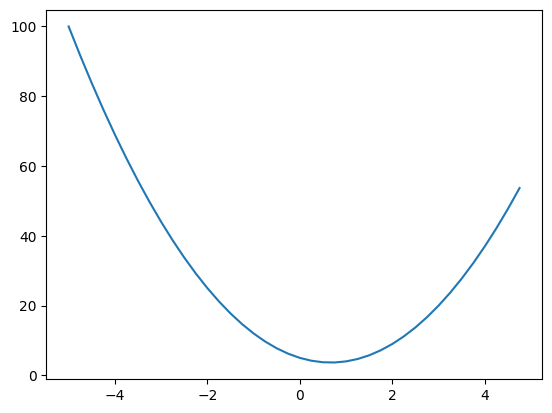

In [5]:
xs = np.arange(-5,5,0.25) 
ys = f(xs)
plt.plot(xs,ys)

In [6]:
h =0.0001
x=3 
print((f(x+h)-f(x))/h)

14.000300000063248


In [7]:
#little complex example 
h = 0.0001 # closer to 0 value 

a= 2.0
b= -3.0
c=10.0
d = a*b + c 
print(d)


4.0


In [8]:
#bump up a by a very small value 
#since b is negative and a is multiplied by b 
#incase you increase a, b is negative - so overall it adds lesser to d 
#hence you get the value -3.0000xx


h = 0.0001 # closer to 0 value 

a= 2.0
b= -3.0
c=10.0
d1 = a*b + c 
a+=h
d2= a*b + c 
print('d1 is',d1)
print('d2 is', d2)
print('slope is', ((d2-d1)/h))

print('a has a negative influence on d with a strength of 3.')


d1 is 4.0
d2 is 3.999699999999999
slope is -3.000000000010772
a has a negative influence on d with a strength of 3.


In [9]:
#bump up a by b very small value 
#since a is negative and b is multiplied by a 
#incase you increase b, a is positive - so overall it adds more to d 
#hence you get the value 2.000


h = 0.0001 # closer to 0 value 

a= 2.0
b= -3.0
c=10.0
d1 = a*b + c 
b+=h
d2= a*b + c 
print('d1 is',d1)
print('d2 is', d2)
print('slope is', ((d2-d1)/h))

print('Slope = 2 means:If I increase b by a very small amount, the value of d increases twice as much as the increase in b.')

#In other words:

#For every +1 change in b, d changes by +2.
#b has a sensitivity of 2 with respect to d.

d1 is 4.0
d2 is 4.0002
slope is 2.0000000000042206
Slope = 2 means:If I increase b by a very small amount, the value of d increases twice as much as the increase in b.


In [10]:

h = 0.0001 # closer to 0 value 

a= 2.0
b= -3.0
c=10.0
d1 = a*b + c 
c+=h
d2= a*b + c 
print('d1 is',d1)
print('d2 is', d2)
print('slope is', ((d2-d1)/h))


d1 is 4.0
d2 is 4.0001
slope is 0.9999999999976694


In [11]:
"""
FINAL SUMMARY: Understanding Derivatives & Slopes (Numerical Differentiation)

This block is purely for learning purposes.

What does the derivative (slope) mathematically mean?
-------------------------------------------------------
The derivative of a function f with respect to x is defined as:

    derivative/slope = (f(x + h) - f(x)) / h     where h is very close to 0

In simple terms:
- We have a function that depends on several variables.
- We slightly bump up one variable by a tiny value 'h'.
- how much does the function fluctuate ? 
- This tells us: "how sensitive is the function with regards to that particular bumped up variable ?"

This sensitivity is called the **slope** or **derivative** (gradient).

Example Function:
----------------
d = a * b + c

Here, a, b, and c are the contributors (inputs) to the function d.

Numerical Example:
-----------------
h = 0.0001          # very small value
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c      # = 4.0

# Bump up 'b' slightly
b += h
d2 = a * b + c      # ≈ 4.0002

slope = (d2 - d1) / h   # Result ≈ 2.0

What does Slope = 2 mean?
-------------------------
→ For every +1 increase in b, the value of d increases by +2.

→ b has a sensitivity (influence) of 2 with respect to d.

→ This number 2 is the derivative (∂d/∂b) of d with respect to b.

Real-life Analogy:
------------------
Think of 'd' as your final score.
Think of 'b' as one of the inputs.

If you increase b a little bit, your final score increases **twice as fast**.
Even though b is negative (-3), making it slightly less negative still improves d at a rate of 2.

This concept is fundamental in neural networks and backpropagation.
"""



'\nFINAL SUMMARY: Understanding Derivatives & Slopes (Numerical Differentiation)\n\nThis block is purely for learning purposes.\n\nWhat does the derivative (slope) mathematically mean?\n-------------------------------------------------------\nThe derivative of a function f with respect to x is defined as:\n\n    derivative/slope = (f(x + h) - f(x)) / h     where h is very close to 0\n\nIn simple terms:\n- We have a function that depends on several variables.\n- We slightly bump up one variable by a tiny value \'h\'.\n- how much does the function fluctuate ? \n- This tells us: "how sensitive is the function with regards to that particular bumped up variable ?"\n\nThis sensitivity is called the **slope** or **derivative** (gradient).\n\nExample Function:\n----------------\nd = a * b + c\n\nHere, a, b, and c are the contributors (inputs) to the function d.\n\nNumerical Example:\n-----------------\nh = 0.0001          # very small value\na = 2.0\nb = -3.0\nc = 10.0\n\nd1 = a * b + c      #

In [92]:
 #moving to neural networks 
#it will have massive mathematical expressions
#create a class that can hold this expression
#example expression being : d1 = a*b + c 

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 #initially gradient is 0 which means chanign this variable does not change L/does not impact LOSS function
        self._backward = lambda : None 
        self._prev=set(_children)
        self._op = _op
        self.label = label 
      
        
    def __repr__(self):
        return f"Value(data={self.data})"


    def __add__(self, other):
        out = Value(self.data+other.data, (self, other), '+')

        def _backward(): # so why is this backward function inside the operator overloaders ?? _backward has to propagate the gradients to the values that created it- then each Value node should save a lit of children and change he grads of the chidlren and code gets real messy .
            #__add__ function knows what variables are being added - in other terms the child nodes which actually make up this node, so the gradiesnt have to be propagated to its children 
            self.grad = 1*out.grad
            other.grad = 1*out.grad 
        out._backward = _backward
        return out
        

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other ), '*')

        def _backward():
            self.grad = other.data * out.grad 
            other.grad = self.data * out.grad 

        out._backward =_backward 
        return out

    def tanh(self):
        x=self.data
        o=((math.exp(2*x)-1)/(math.exp(2*x)+1))
        out = Value(o, (self,),label='tanh')

        def _backward():
            self.grad = (1-o**2) * out.grad # out.grad is chai ned with the local derivative into self.grad 
        
        out._backward = _backward 
        return out






In [93]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label,n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

Value(data=-8.0)

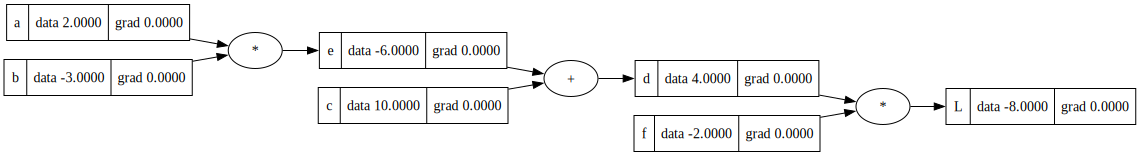

'micrograd_graph.png'

Graph saved as micrograd_graph.png


In [94]:
# Test rendering with explicit render
# TRY OUT Value class and graoh vendoring for  a random equation and see the graphn   
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L


dot = draw_dot(L)

# Method 1: Try to display
dot

# Method 2: Save as PNG (this should create the file)
try:
    dot.render('micrograd_graph', format='png', cleanup=True, view=False)
    print("Graph saved as micrograd_graph.png")
except Exception as e:
    print("Error:", e)

In [95]:
 # the above diagram can be visualized as .. 
#L is the loss function. 
#we are going to find derivcative of L with respect to the weights of the neural net vis back propagation
#e are going to find the derivative of L with respect to the weights of data and not the data itself. data is going ot be fixed. weights are going to change 

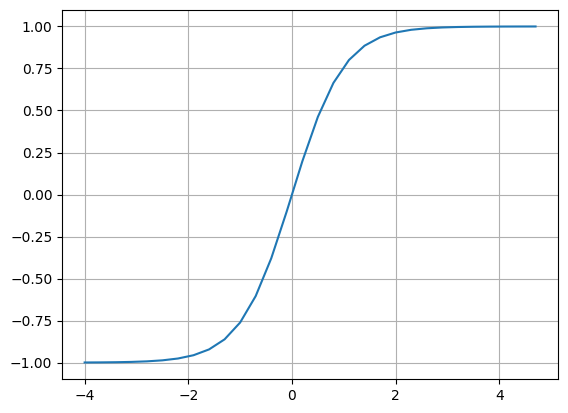

In [96]:
plt.plot(np.arange(-4,5,0.3), np.tanh(np.arange(-4,5,0.3)));plt.grid();

In [97]:
# setting up of nodes - SETTING UP OF INPUT NODES TO MIMIC NEURON STRUCTURE 
#inputs 
x1=Value(2.0,label='x1')
x2=Value(0,label='x2')

#weights
w1 =Value(-3.0,label='w1')
w2=Value(1.0,label='w2')

#bias 
b=Value(6.8813735870195432, label='b')


x1w1=x1*w1; x1w1.label='x1w1'
x2w2=x2*w2; x2w2.label='x2w2'

#cell body function 
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w1'
n= x1w1x2w2+b;n.label='n'

o=n.tanh();o.label='o'




In [98]:
#MANUAL BACK PROPAGATION THROUGH NEURON 
# step 1 : find gradient of o node- last node - its fixed - its going to be 1
o.grad=1.0;

"""@step 2 : find gradient of node n 
 we know o = tanh(n)
do/dn ---> to find the gradient of n node 
new formula for today-> differentiate tanh 
formula: 1-tanh(x)**2 ps: ** means square 

applying to our tanh 
o=tanh(n)
do/dn = 1-tanh(n)**2
do/dn = 1- o**2*/

 """

n.grad = 1 - (o.data **2);

"""step 3 : find gradient of nodes x1w1 + x2w1 and b , since the operation is 1, the gradient is just passed on from the next node into this without any changes """

x1w1x2w2.grad=n.grad
b.grad = n.grad

x1w1.grad = n.grad
x2w2.grad=n.grad

"""step 3 : find gradient of nodes X1 , W1, X2, W2  

w1, w2 are the weights that we care about. need to understand how it incfluences the final function so that we can adjust w1, w2 to maximum our final value

the final function we have chosen here is a tanh, but it doesnt have to do.. it can be tanh or any arbitrarily simple function , only thing is you should be able to calculate the local derivative 
of each weight with respect to the final function that you choose. just know how the variables can influence the final function 

now trick to find derivatives of w1 and w2 -with operation * being the local operation 

usually in terms of multiplication 

for eg: derivative of w2  = x2.data * x2w2.grad 
        derivative of x2 = w2.data * x2w2.grad 

        derivative of w1 = x1.data * x1w1.grad
        derivative of x1 = w1.data * x1w1.grad 
"""

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

"""
another obervation is :


w2 is always multiplied with x2 which is 0, so the influence of w2 should be none - hence w2.grad = 0 makes total sense 
"""









'@step 2 : find gradient of node n \n we know o = tanh(n)\ndo/dn ---> to find the gradient of n node \nnew formula for today-> differentiate tanh \nformula: 1-tanh(x)**2 ps: ** means square \n\napplying to our tanh \no=tanh(n)\ndo/dn = 1-tanh(n)**2\ndo/dn = 1- o**2*/\n\n '

'step 3 : find gradient of nodes x1w1 + x2w1 and b , since the operation is 1, the gradient is just passed on from the next node into this without any changes '

'step 3 : find gradient of nodes X1 , W1, X2, W2  \n\nw1, w2 are the weights that we care about. need to understand how it incfluences the final function so that we can adjust w1, w2 to maximum our final value\n\nthe final function we have chosen here is a tanh, but it doesnt have to do.. it can be tanh or any arbitrarily simple function , only thing is you should be able to calculate the local derivative \nof each weight with respect to the final function that you choose. just know how the variables can influence the final function \n\nnow trick to find derivatives of w1 and w2 -with operation * being the local operation \n\nusually in terms of multiplication \n\nfor eg: derivative of w2  = x2.data * x2w2.grad \n        derivative of x2 = w2.data * x2w2.grad \n\n        derivative of w1 = x1.data * x1w1.grad\n        derivative of x1 = w1.data * x1w1.grad \n'

'\nanother obervation is :\n\n\nw2 is always multiplied with x2 which is 0, so the influence of w2 should be none - hence w2.grad = 0 makes total sense \n'

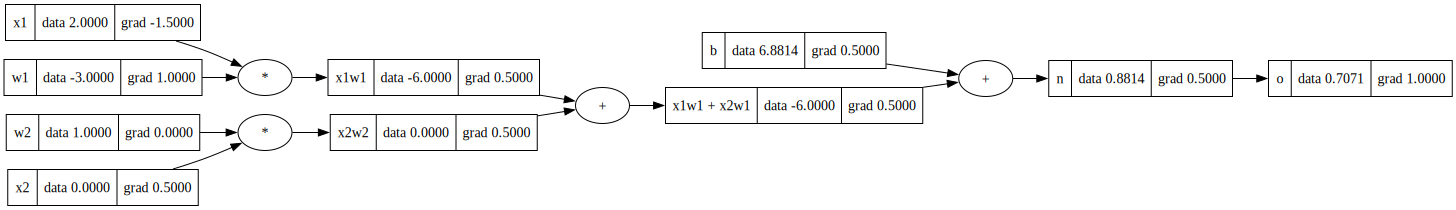

In [99]:
draw_dot(o)

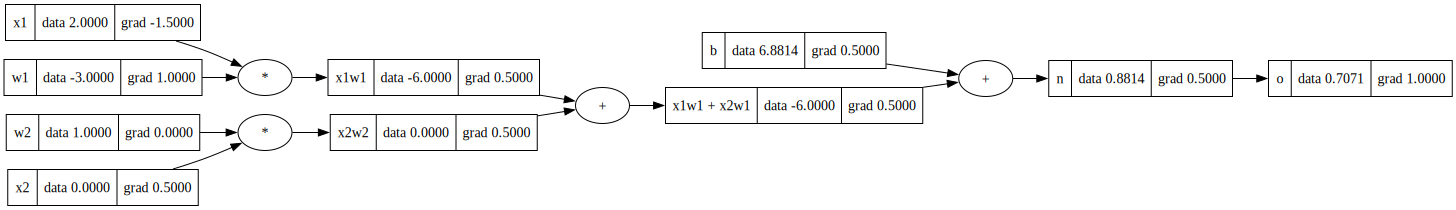

In [100]:
# back propagation via code May 30 
o.grad = 1 
o._backward() 
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
draw_dot(o)

In [ ]:
#back propagation 